# Exercise 04: Wikipedia Vote Network

Connectivity, articulation points, and resilience analysis of the Wikipedia admin-election vote network.

In [24]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

## Load Data

**Citation:** J. Leskovec, D. Huttenlocher, and J. Kleinberg. Signed networks in social media. CHI 2010.

In [25]:
data_path = Path('data/wiki-Vote.txt')
G = nx.DiGraph()

with open(data_path, 'r') as f:
    for line in f:
        line = line.strip()
        if line.startswith('#'):
            continue
        if not line:
            continue
        parts = line.split('\t')
        if len(parts) >= 2:
            u, v = int(parts[0]), int(parts[1])
            G.add_edge(u, v)

print(f"Graph loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Graph loaded: 7115 nodes, 103689 edges


## Connectivity Analysis

For a directed graph we report both **weakly connected components** (WCCs, ignoring edge direction) and **strongly connected components** (SCCs, requiring mutual reachability along directed edges). These two metrics tell very different stories about how connected the network really is.

**WCC vs SCC:** WCC connectivity is broad: most voters are reachable ignoring edge direction. SCC connectivity is strict: it requires following directed vote edges both ways. The gap between these two measures shows how much direction fragments the network.

In [26]:
wccs = list(nx.weakly_connected_components(G))
wcc_sizes = sorted([len(c) for c in wccs], reverse=True)

sccs = list(nx.strongly_connected_components(G))
scc_sizes = sorted([len(c) for c in sccs], reverse=True)

n_nodes = G.number_of_nodes()

print(f"Total WCCs: {len(wccs)}")
print(f"Largest WCC: {wcc_sizes[0]} nodes ({100 * wcc_sizes[0] / n_nodes:.1f}% of all nodes)")
if len(wcc_sizes) > 1:
    print(f"Second largest WCC: {wcc_sizes[1]} nodes")
print(f"Singleton WCCs (isolated nodes): {sum(1 for s in wcc_sizes if s == 1)}")
print(f"WCC sizes (top 10): {wcc_sizes[:10]}")

print(f"Total SCCs: {len(sccs)}")
print(f"Largest SCC: {scc_sizes[0]} nodes ({100 * scc_sizes[0] / n_nodes:.1f}% of all nodes)")
if len(scc_sizes) > 1:
    print(f"Second largest SCC: {scc_sizes[1]} nodes")
print(f"Singleton SCCs: {sum(1 for s in scc_sizes if s == 1)}")
print(f"SCC sizes (top 10): {scc_sizes[:10]}")

Total WCCs: 24
Largest WCC: 7066 nodes (99.3% of all nodes)
Second largest WCC: 3 nodes
Singleton WCCs (isolated nodes): 0
WCC sizes (top 10): [7066, 3, 3, 3, 2, 2, 2, 2, 2, 2]
Total SCCs: 5816
Largest SCC: 1300 nodes (18.3% of all nodes)
Second largest SCC: 1 nodes
Singleton SCCs: 5815
SCC sizes (top 10): [1300, 1, 1, 1, 1, 1, 1, 1, 1, 1]


## Articulation Points and Bridges

**Directed graph adaptation:** Standard articulation-point and bridge algorithms are defined only for undirected graphs. We apply them to the **undirected projection** of the vote network, treating every directed edge as undirected. This identifies nodes and edges whose removal would disconnect the network regardless of vote direction.

In [27]:
from collections import deque

G_und = G.to_undirected()

# --- Articulation Points ---
art_points = list(nx.articulation_points(G_und))
art_by_degree = sorted(art_points, key=lambda n: G.degree(n), reverse=True)

print(f"Total articulation points: {len(art_points)}")
if art_by_degree:
    print("| Rank | Node | Total Degree | In-Degree | Out-Degree |")
    print("|------|------|--------------|-----------|------------|")
    for rank, node in enumerate(art_by_degree[:10], 1):
        print(f"| {rank} | {node} | {G.degree(node)} | {G.in_degree(node)} | {G.out_degree(node)} |")

# --- Bridges ---
bridges = list(nx.bridges(G_und))
print(f"Total bridges: {len(bridges)}")

best_bridge_undirected = None
best_secondary_size = 0

if bridges:
    # Compute 2-edge-connected components (2ECCs) by removing all bridges.
    # Each remaining connected component is a 2ECC (or isolated node).
    G_no_bridges = G_und.copy()
    for u, v in bridges:
        if G_no_bridges.has_edge(u, v):
            G_no_bridges.remove_edge(u, v)
    two_eccs = list(nx.connected_components(G_no_bridges))
    node_to_ecc = {n: i for i, ecc in enumerate(two_eccs) for n in ecc}

    # Build bridge tree: 2ECCs as nodes, bridges as edges
    BT = nx.Graph()
    for i, ecc in enumerate(two_eccs):
        BT.add_node(i, count=len(ecc))
    for u, v in bridges:
        eu, ev = node_to_ecc[u], node_to_ecc[v]
        if eu != ev and not BT.has_edge(eu, ev):
            BT.add_edge(eu, ev, orig=(u, v))

    # BFS subtree sizes rooted at the largest 2ECC
    root = max(BT.nodes(), key=lambda i: BT.nodes[i]["count"])
    par = {root: None}
    bfs_order = [root]
    q = deque([root])
    while q:
        v = q.popleft()
        for u in BT.neighbors(v):
            if u not in par:
                par[u] = v
                q.append(u)
                bfs_order.append(u)

    sub = {v: BT.nodes[v]["count"] for v in bfs_order}
    for v in reversed(bfs_order):
        if par[v] is not None:
            sub[par[v]] += sub[v]

    total_nodes = G_und.number_of_nodes()

    # Find centroid bridge: maximises secondary component size
    for eu, ev in BT.edges():
        child = ev if par.get(ev) == eu else eu
        if child not in sub:
            continue
        sec = min(sub[child], total_nodes - sub[child])
        if sec > best_secondary_size:
            best_secondary_size = sec
            best_bridge_undirected = BT.edges[eu, ev]["orig"]

    leaf_bridges = sum(1 for u, v in bridges
                       if G_und.degree(u) == 1 or G_und.degree(v) == 1)
    print(f"  Leaf bridges (one endpoint with undirected degree=1): {leaf_bridges}")
    print(f"  Non-trivial bridges (both endpoints degree>1): {len(bridges) - leaf_bridges}")
    if best_bridge_undirected:
        bu, bv = best_bridge_undirected
        print(f"Most impactful bridge (bridge tree centroid): ({bu}, {bv})")
        print(f"  Degrees in directed graph — node {bu}: {G.degree(bu)}, node {bv}: {G.degree(bv)}")
        print(f"  Secondary component size on removal: {best_secondary_size} node(s)")

Total articulation points: 1033
| Rank | Node | Total Degree | In-Degree | Out-Degree |
|------|------|--------------|-----------|------------|
| 1 | 2565 | 1167 | 274 | 893 |
| 2 | 766 | 773 | 0 | 773 |
| 3 | 1166 | 743 | 144 | 599 |
| 4 | 457 | 732 | 0 | 732 |
| 5 | 1374 | 551 | 89 | 462 |
| 6 | 1151 | 543 | 71 | 472 |
| 7 | 5524 | 538 | 149 | 389 |
| 8 | 3352 | 537 | 264 | 273 |
| 9 | 2485 | 484 | 160 | 324 |
| 10 | 2328 | 481 | 266 | 215 |
Total bridges: 2306
  Leaf bridges (one endpoint with undirected degree=1): 2295
  Non-trivial bridges (both endpoints degree>1): 11
Most impactful bridge (bridge tree centroid): (163, 6691)
  Degrees in directed graph — node 163: 23, node 6691: 5
  Secondary component size on removal: 5 node(s)


## Critical Node Removal

We remove the highest-degree articulation point. After removal we recompute WCC and SCC counts and sizes to measure structural impact.

In [28]:
if art_by_degree:
    critical_node = art_by_degree[0]
else:
    # Fallback: highest total degree node
    critical_node = max(G.nodes(), key=lambda n: G.degree(n))

G_no_node = G.copy()
G_no_node.remove_node(critical_node)

wccs_nn = list(nx.weakly_connected_components(G_no_node))
wcc_sizes_nn = sorted([len(c) for c in wccs_nn], reverse=True)
sccs_nn = list(nx.strongly_connected_components(G_no_node))
scc_sizes_nn = sorted([len(c) for c in sccs_nn], reverse=True)

print(f"Node {critical_node} removed — degree: {G.degree(critical_node)} (in: {G.in_degree(critical_node)}, out: {G.out_degree(critical_node)})")
print(f"WCC count: {len(wccs)} → {len(wccs_nn)} (change: +{len(wccs_nn) - len(wccs)})")
print(f"Largest WCC: {wcc_sizes[0]} → {wcc_sizes_nn[0]} nodes (change: {wcc_sizes_nn[0] - wcc_sizes[0]})")
print(f"SCC count: {len(sccs)} → {len(sccs_nn)} (change: +{len(sccs_nn) - len(sccs)})")
print(f"Largest SCC: {scc_sizes[0]} → {scc_sizes_nn[0]} nodes (change: {scc_sizes_nn[0] - scc_sizes[0]})")

Node 2565 removed — degree: 1167 (in: 274, out: 893)
WCC count: 24 → 28 (change: +4)
Largest WCC: 7066 → 7061 nodes (change: -5)
SCC count: 5816 → 5817 (change: +1)
Largest SCC: 1300 → 1298 nodes (change: -2)


## Critical Edge Removal

We remove the **most impactful bridge**: the one whose removal creates the largest secondary component, found via bridge tree analysis. This is a stronger criterion than picking by endpoint degree, which often just selects trivial leaf bridges attached to high-degree hubs.

In [29]:
if bridges and best_bridge_undirected:
    bu, bv = best_bridge_undirected
    # Determine which directed edge exists (bridge tree works on undirected projection)
    if G.has_edge(bu, bv) and not G.has_edge(bv, bu):
        critical_edge = (bu, bv)
        edge_type = f"most impactful bridge — splits off {best_secondary_size} node(s) from giant WCC"
    elif G.has_edge(bv, bu) and not G.has_edge(bu, bv):
        critical_edge = (bv, bu)
        edge_type = f"most impactful bridge — splits off {best_secondary_size} node(s) from giant WCC"
    elif G.has_edge(bu, bv):
        # Both directions present: removing one directed edge won't disconnect WCC,
        # but is still the structurally most significant edge by secondary component.
        critical_edge = (bu, bv)
        edge_type = (f"most impactful bridge (bidirectional in directed graph — "
                     f"WCC remains connected on single edge removal, SCC impact measured)")
    else:
        critical_edge = list(G.edges())[0]
        edge_type = "fallback"
elif bridges:
    bridge_candidates = []
    for u, v in bridges:
        if G.has_edge(u, v):
            bridge_candidates.append((u, v, G.degree(u) + G.degree(v)))
        if G.has_edge(v, u):
            bridge_candidates.append((v, u, G.degree(v) + G.degree(u)))
    bridge_candidates.sort(key=lambda x: x[2], reverse=True)
    critical_edge = (bridge_candidates[0][0], bridge_candidates[0][1])
    edge_type = "bridge (highest combined degree)"
else:
    top_art = art_by_degree[0] if art_by_degree else critical_node
    candidates = []
    for nbr in G_und.neighbors(top_art):
        if G.has_edge(top_art, nbr):
            candidates.append((top_art, nbr, G.degree(top_art) + G.degree(nbr)))
        if G.has_edge(nbr, top_art):
            candidates.append((nbr, top_art, G.degree(nbr) + G.degree(top_art)))
    candidates.sort(key=lambda x: x[2], reverse=True)
    critical_edge = (candidates[0][0], candidates[0][1]) if candidates else list(G.edges())[0]
    edge_type = "high-degree edge (no bridges exist in undirected projection)"

G_no_edge = G.copy()
G_no_edge.remove_edge(*critical_edge)

wccs_ne = list(nx.weakly_connected_components(G_no_edge))
wcc_sizes_ne = sorted([len(c) for c in wccs_ne], reverse=True)
sccs_ne = list(nx.strongly_connected_components(G_no_edge))
scc_sizes_ne = sorted([len(c) for c in sccs_ne], reverse=True)

print(f"Critical edge: {critical_edge} ({edge_type})")
print(f"Endpoint degrees: node {critical_edge[0]} degree={G.degree(critical_edge[0])}, node {critical_edge[1]} degree={G.degree(critical_edge[1])}")
print(f"WCC count: {len(wccs)} → {len(wccs_ne)} (change: +{len(wccs_ne) - len(wccs)})")
print(f"Largest WCC: {wcc_sizes[0]} → {wcc_sizes_ne[0]} nodes (change: {wcc_sizes_ne[0] - wcc_sizes[0]})")
print(f"SCC count: {len(sccs)} → {len(sccs_ne)} (change: +{len(sccs_ne) - len(sccs)})")
print(f"Largest SCC: {scc_sizes[0]} → {scc_sizes_ne[0]} nodes (change: {scc_sizes_ne[0] - scc_sizes[0]})")

Critical edge: (163, 6691) (most impactful bridge — splits off 5 node(s) from giant WCC)
Endpoint degrees: node 163 degree=23, node 6691 degree=5
WCC count: 24 → 25 (change: +1)
Largest WCC: 7066 → 7061 nodes (change: -5)
SCC count: 5816 → 5816 (change: +0)
Largest SCC: 1300 → 1300 nodes (change: 0)


## Before/After Summary Table

In [30]:
summary = {
    'Metric': [
        'Nodes', 'Edges',
        'WCC count', 'Largest WCC size', 'Largest WCC %',
        'SCC count', 'Largest SCC size', 'Largest SCC %'
    ],
    'Original': [
        G.number_of_nodes(), G.number_of_edges(),
        len(wccs), wcc_sizes[0], f"{100 * wcc_sizes[0] / G.number_of_nodes():.1f}%",
        len(sccs), scc_sizes[0], f"{100 * scc_sizes[0] / G.number_of_nodes():.1f}%"
    ],
    f'After Node {critical_node} Removed': [
        G_no_node.number_of_nodes(), G_no_node.number_of_edges(),
        len(wccs_nn), wcc_sizes_nn[0], f"{100 * wcc_sizes_nn[0] / G_no_node.number_of_nodes():.1f}%",
        len(sccs_nn), scc_sizes_nn[0], f"{100 * scc_sizes_nn[0] / G_no_node.number_of_nodes():.1f}%"
    ],
    f'After Edge {critical_edge} Removed': [
        G_no_edge.number_of_nodes(), G_no_edge.number_of_edges(),
        len(wccs_ne), wcc_sizes_ne[0], f"{100 * wcc_sizes_ne[0] / G_no_edge.number_of_nodes():.1f}%",
        len(sccs_ne), scc_sizes_ne[0], f"{100 * scc_sizes_ne[0] / G_no_edge.number_of_nodes():.1f}%"
    ]
}

df = pd.DataFrame(summary)
print(df.to_markdown(index=False))

ImportError: Missing optional dependency 'tabulate'.  Use pip or conda to install tabulate.

## Visualization

Component size distributions for WCC and SCC, original vs. after critical node removal. Log scale because the giant component dwarfs all others.

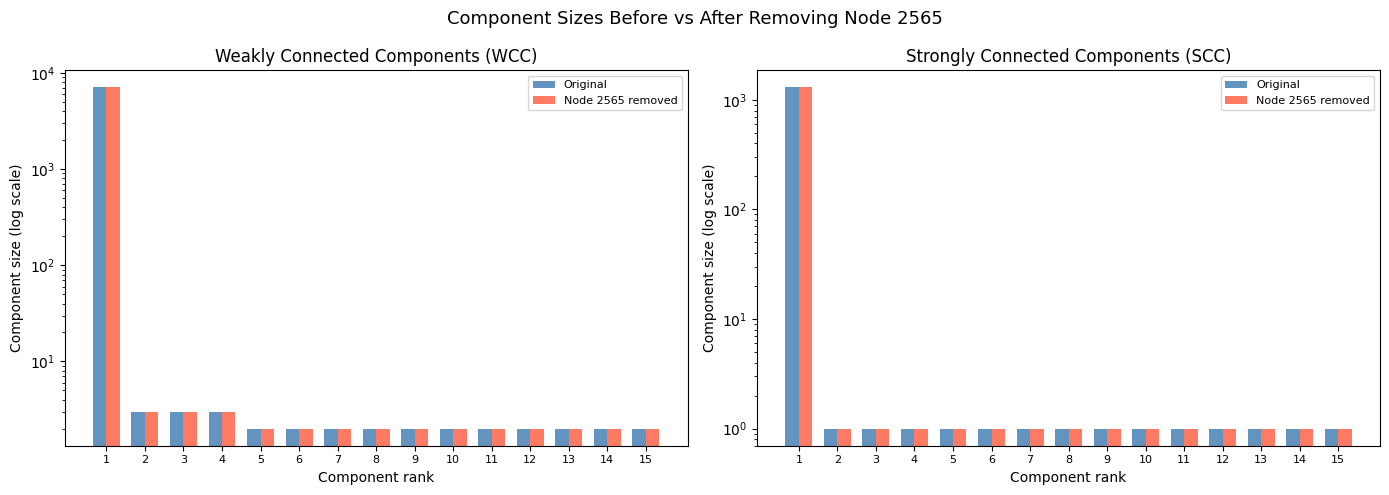

In [ ]:
n_top = 15

def pad(sizes, n):
    return (sizes + [0] * n)[:n]

orig_wcc = pad(wcc_sizes, n_top)
nn_wcc = pad(wcc_sizes_nn, n_top)
orig_scc = pad(scc_sizes, n_top)
nn_scc = pad(scc_sizes_nn, n_top)

x = np.arange(n_top)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Component Sizes Before vs After Removing Node {critical_node}', fontsize=13)

for ax, orig, after, title in [
    (axes[0], orig_wcc, nn_wcc, 'Weakly Connected Components (WCC)'),
    (axes[1], orig_scc, nn_scc, 'Strongly Connected Components (SCC)')
]:
    orig_plot = [max(v, 0.5) for v in orig]
    after_plot = [max(v, 0.5) for v in after]
    ax.bar(x - width/2, orig_plot, width, label='Original', color='steelblue', alpha=0.85)
    ax.bar(x + width/2, after_plot, width, label=f'Node {critical_node} removed', color='tomato', alpha=0.85)
    ax.set_yscale('log')
    ax.set_xlabel('Component rank')
    ax.set_ylabel('Component size (log scale)')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([str(i + 1) for i in range(n_top)], fontsize=8)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('connectivity_viz.png', dpi=150, bbox_inches='tight')
plt.show()

## Resilience Note

**WCC level: very robust.** The dense voting activity creates many redundant paths, so ignoring direction the network holds together almost perfectly.

**SCC level: already fragmented.** Mutual reachability along directed vote edges is confined to a small core. This is a classic bow-tie: a mutual-voting core surrounded by a periphery of one-way voters who never receive a reciprocal vote.

**Articulation points.** Even the highest-degree articulation point has minimal impact on WCC structure, confirming strong undirected redundancy.

**Bridges.** All bridges in this network are peripheral leaf connections: they attach isolated small groups to the giant component but do not separate major sub-communities from each other. No single edge removal can fragment the giant WCC into two large pieces.

**Overall verdict:** At the WCC level the Wikipedia vote network has strong redundancy; removing a single node or edge barely affects reachability. The true fragility is structural and directional: the SCC core is already a tiny fraction of the network, and the remaining voters exist outside any directed feedback loop. Any disruption to the mutual-voting core directly reduces the fraction of nodes that can influence each other.

In [ ]:
wcc_giant_pct = 100 * wcc_sizes[0] / G.number_of_nodes()
scc_giant_pct = 100 * scc_sizes[0] / G.number_of_nodes()
n_art = len(art_points)
n_bridges = len(bridges)
wcc_delta_node = len(wccs_nn) - len(wccs)
scc_delta_node = len(sccs_nn) - len(sccs)
largest_wcc_drop = wcc_sizes[0] - wcc_sizes_nn[0]

print(f"WCC giant component: {wcc_giant_pct:.1f}% of nodes")
print(f"SCC giant component: {scc_giant_pct:.1f}% of nodes — core of {scc_sizes[0]} nodes, {len(sccs) - 1} non-giant components")
print(f"Articulation points: {n_art} | Critical node {critical_node} (degree {G.degree(critical_node)}): +{wcc_delta_node} WCCs, -{largest_wcc_drop} giant WCC nodes")
print(f"Bridges: {n_bridges} | Most impactful: {best_bridge_undirected}, splits off {best_secondary_size} node(s)")

WCC giant component: 99.3% of nodes
SCC giant component: 18.3% of nodes — core of 1300 nodes, 5815 non-giant components
Articulation points: 1033 | Critical node 2565 (degree 1167): +4 WCCs, -5 giant WCC nodes
Bridges: 2306 | Most impactful: (163, 6691), splits off 5 node(s)
